# 该脚本用于生成检测板模型

基于背景模型，在该模型上添加 速度扰动 和 各向异性扰动。其形式满足sin函数形式

In [17]:
# 载入 PyTomoATT 模块
# 文档：https://tomoatt.github.io/PyTomoATT/index.html

import pytomoatt as pyt

import numpy as np

# 1. 创建 PyTomoATT 模型对象

In [18]:
# TomoATT 参数文件目录，主要用于读取文件中的研究范围
par_file = "../3_input_params/input_params_step1_1D_inv.yaml"

# 读取参数文件，生成 ATTModel 对象
att_model = pta.ATTModel(par_file)

# 该模型的三维网格信息包括
n_rtp          = att_model.n_rtp       # 三个方向的网格节点数 r (depth), t (longtitude), p (latitude) directions
am_depths      = att_model.depths      # r方向 深度 (km)
am_latitudes   = att_model.latitudes   # p方向 纬度 (degree)
am_longitudes  = att_model.longitudes  # t方向 经度 (degree)

# 输出查看网格坐标信息
# print("grid node numbers (N_r, N_t, N_p):", n_rtp)
# print("depths (km):", am_depths)
# print("latitudes (degree):", am_latitudes)
# print("longitudes (degree):", am_longitudes)

# 2. 检测板模型-速度扰动

速度异常的尺寸设置为  1度_1度_10km

In [19]:
# 设置参数
lim_x       = [-1.5, 1.5]   # 放置检测板的 x(lon) 范围
lim_y       = [-2.5, 3.5]   # 放置检测板的 y(lat) 范围
lim_z       = [0, 20]       # 放置检测板的 z(dep) 范围

n_pert_x    = 3             # 在 x (lon) 方向范围内放置的检测板块数量（一红一蓝，表示两块检测板异常）
n_pert_y    = 6             # 在 y (lat) 方向范围内放置的检测板块数量
n_pert_z    = 2             # 在 z (dep) 方向范围内放置的检测板块数量

pert_vel    = 0.05          # 速度扰动幅度 （0.05表示 10% 的 异常扰动）
pert_ani    = 0.00          # 各向异性扰动幅度
ani_dir     = 60.0          # 各向异性快轴方向 （相对x轴，逆时针角度）

bg_model_fname = "../OUTPUT_FILES/OUTPUT_FILES_step1_1D_inv/final_model.h5"  # 背景模型文件名

In [20]:
# 创建 检测板 模型对象
ckb_vel = pta.Checker(bg_model_fname, para_fname=par_file)

# 生成 检测板 模型
ckb_vel.checkerboard(
    n_pert_x=n_pert_x, n_pert_y=n_pert_y, n_pert_z=n_pert_z,         
    pert_vel=pert_vel, pert_ani=pert_ani, ani_dir=ani_dir,   
    lim_x=lim_x, lim_y=lim_y, lim_z=lim_z
)

# 3. 检测板模型-各向异性扰动

一般情况下，各向异性的准确反演对数据要求更高。因此，在同样数据条件下，各向异性检测板的尺寸通常应该小于速度异常体。

这样，我们将各向异性异常体的尺寸设置为 1.5度_1.5度_10km

In [21]:
# 设置参数
lim_x       = [-1.5, 1.5]   # 放置检测板的 x(lon) 范围
lim_y       = [-2.5, 3.5]   # 放置检测板的 y(lat) 范围
lim_z       = [0, 20]       # 放置检测板的 z(dep) 范围

n_pert_x    = 2             # 在 x (lon) 方向范围内放置的检测板块数量
n_pert_y    = 4             # 在 y (lat) 方向范围内放置的检测板块数量
n_pert_z    = 2             # 在 z (dep) 方向范围内放置的检测板块数量

pert_vel    = 0.00          # 速度扰动幅度 （0.05表示 10% 的 异常扰动）
pert_ani    = 0.05          # 各向异性扰动幅度
ani_dir     = 60.0          # 各向异性快轴方向 （相对x轴，逆时针角度）

In [22]:
# 创建 检测板 模型对象
ckb_ani = pta.Checker(bg_model_fname, para_fname=par_file)

# 生成 检测板 模型
ckb_ani.checkerboard(
    n_pert_x=n_pert_x, n_pert_y=n_pert_y, n_pert_z=n_pert_z,         
    pert_vel=pert_vel, pert_ani=pert_ani, ani_dir=ani_dir,   
    lim_x=lim_x, lim_y=lim_y, lim_z=lim_z
)

# 4. 将速度结构扰动与各向异性扰动整合到一个模型中，并输出

In [23]:
# 将速度异常扰动 赋值给各向异性模型的速度异常扰动
ckb_ani.vel_pert = ckb_vel.vel_pert

# 保存 检测板 模型
import os
output_path = "output_model"
os.makedirs(output_path, exist_ok=True)

fname = "%s/model_ckb_N%d_%d_%d.h5" % (output_path, n_rtp[0], n_rtp[1], n_rtp[2])
ckb_ani.write(fname)

# 备份一份到主目录
output_path = "../2_models"
os.makedirs(output_path, exist_ok=True)
fname = "%s/model_ckb_N%d_%d_%d.h5" % (output_path, n_rtp[0], n_rtp[1], n_rtp[2])
ckb_ani.write(fname)

# 5. 模型画图（可选）

该画图脚本需要 PyGMT 模组。链接 https://www.pygmt.org/latest/

surface [WARNING]: 1008 unusable points were supplied; these will be ignored.
surface [WARNING]: You should have pre-processed the data with block-mean, -median, or -mode.
surface [WARNING]: Check that previous processing steps write results with enough decimals.
surface [WARNING]: Possibly some data were half-way between nodes and subject to IEEE 754 rounding.
surface [WARNING]: 1008 unusable points were supplied; these will be ignored.
surface [WARNING]: You should have pre-processed the data with block-mean, -median, or -mode.
surface [WARNING]: Check that previous processing steps write results with enough decimals.
surface [WARNING]: Possibly some data were half-way between nodes and subject to IEEE 754 rounding.


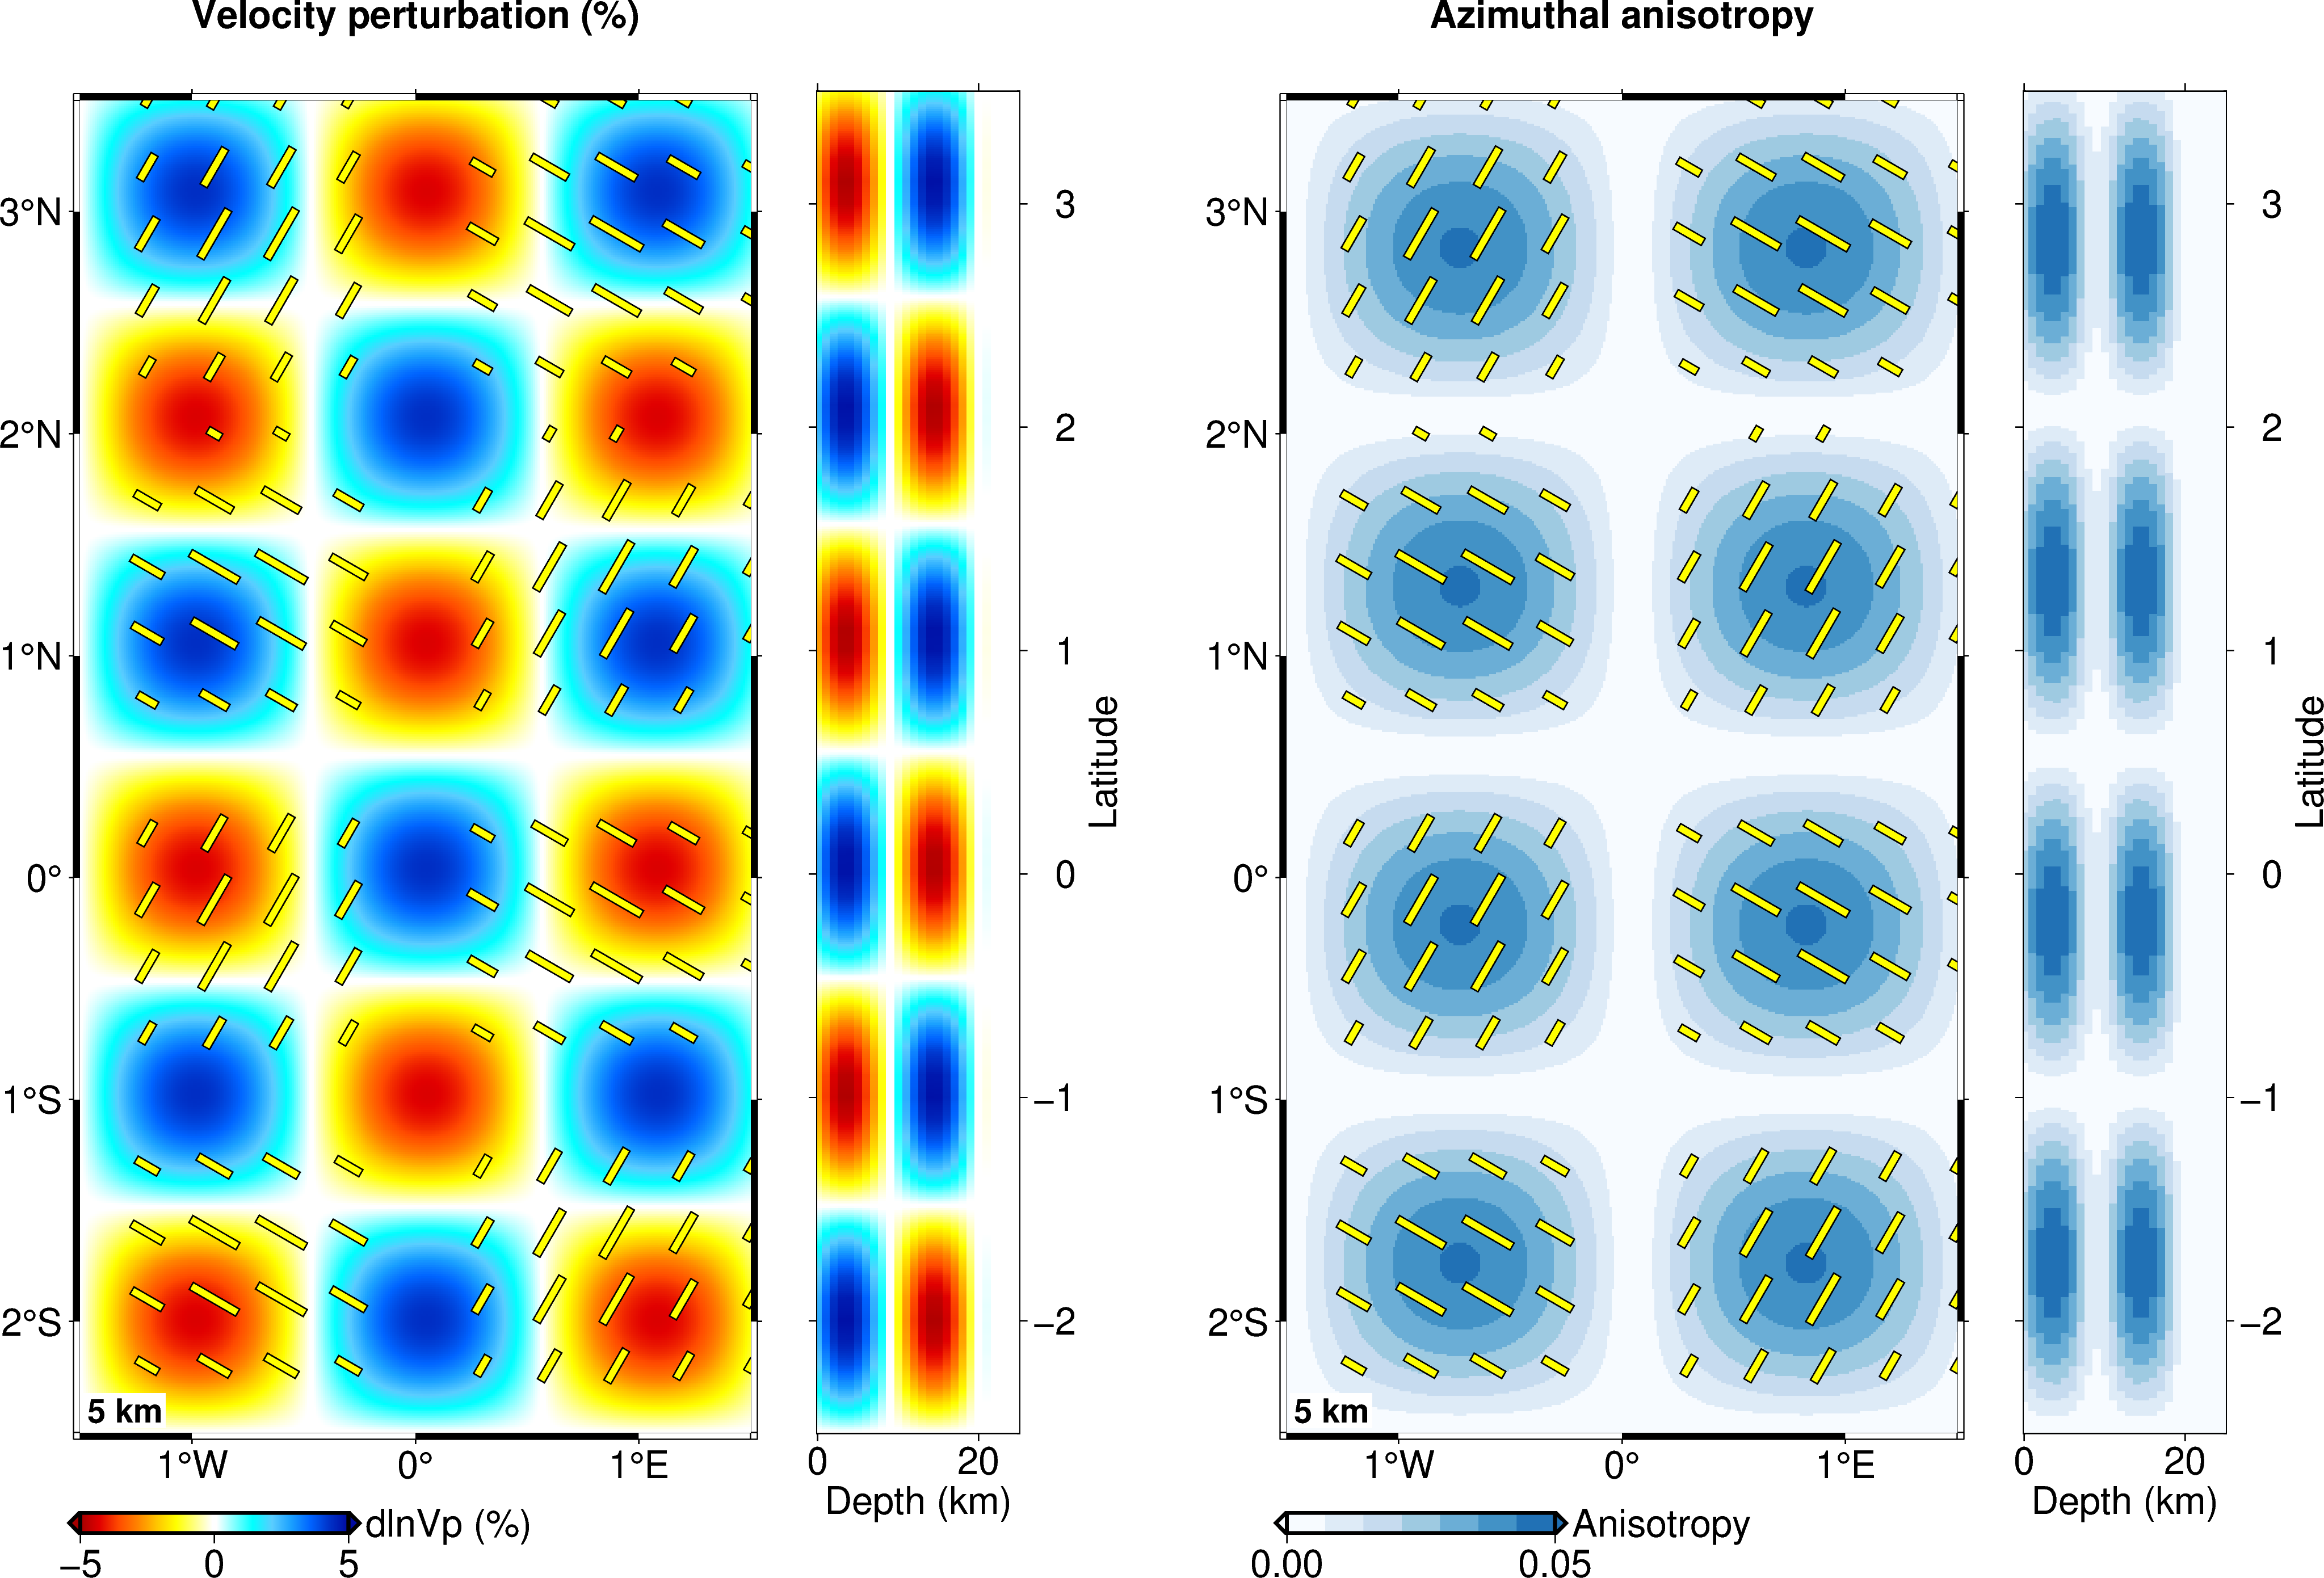

In [24]:
# 载入 PyGMT 模块
import pygmt
pygmt.config(FONT="16p")

# ---------------- read model files ----------------
# file names
init_model_file  = bg_model_fname       # initial model file
ckb_model_file   = fname                # checkerboard model file
par_file         = par_file             # parameter file

# read initial and final model file
att_model = pta.ATTModel.read(init_model_file, par_file)
init_model = att_model.to_xarray()

att_model = pta.ATTModel.read(ckb_model_file, par_file)
ckb_model = att_model.to_xarray()

# interp vel at depth = 5 km
depth = 5.0
vel_init    = init_model.interp_dep(depth, field='vel')    # vel_init[i,:] are (lon, lat, vel)
vel_ckb     = ckb_model.interp_dep(depth, field='vel')    # vel_ckb[i,:] are (lon, lat, vel)

# ----------------- pygmt plot ------------------

fig = pygmt.Figure()
pygmt.makecpt(cmap="../utils/svel13_chen.cpt", series=[-5,5], background=True, reverse=False)    # colorbar


# ------------ plot horizontal profile of velocity ------------
region = [-1.5, 1.5, -2.5, 3.5]    # region of interest
fig.basemap(region=region, frame=["xa1","ya1","+tVelocity perturbation (%)"], projection="M10c")   # base map

prof_init    = init_model.interp_dep(depth, field='vel')    # prof_init[i,:] are (lon, lat, vel)
prof_ckb     = ckb_model.interp_dep(depth, field='vel')    # prof_ckb[i,:] are (lon, lat, vel)
lon = prof_init[:,0]    # longitude
lat = prof_init[:,1]    # latitude
vel_pert = (prof_ckb[:,2] - prof_init[:,2])/prof_init[:,2] * 100    # velocity perturbation related to initial model

grid = pygmt.surface(x=lon, y=lat, z=vel_pert, spacing=0.01,region=region)

fig.grdimage(grid = grid)   # plot figure
fig.text(text="%d km"%(depth), x = region[0] + 0.2 , y = region[2] + 0.1, font = "14p,Helvetica-Bold,black", fill = "white") 

# fast velocity directions (FVDs)
samp_interval = 3   # control the density of anisotropic arrows
width = 0.12        # width of the anisotropic arrow
ani_per_1 = 0.005; ani_per_2 = 0.05; scale = 0.8; basic = 0.2    # control the length of anisotropic arrows related to the amplitude of anisotropy. length = 0.1 + (amplitude - ani_per_1) / (ani_per_2 - ani_per_1) * scale
ani_thd = ani_per_1 # if the amplitude of anisotropy is smaller than ani_thd, no anisotropic arrow will be plotted

phi         = ckb_model.interp_dep(depth, field='phi', samp_interval=samp_interval)          # phi_inv[i,:] are (lon, lat, phi)
epsilon     = ckb_model.interp_dep(depth, field='epsilon', samp_interval=samp_interval)      # epsilon_inv[i,:] are (lon, lat, epsilon)
ani_lon     = phi[:,0].reshape(-1,1)
ani_lat     = phi[:,1].reshape(-1,1)
ani_phi     = phi[:,2].reshape(-1,1)
length      = ((epsilon[:,2] - ani_per_1) / (ani_per_2 - ani_per_1) * scale + basic).reshape(-1,1)
ani_arrow      = np.hstack([ani_lon, ani_lat, ani_phi, length, np.ones((ani_lon.size,1))*width])   # lon, lat, color, angle[-90,90], length, width

# remove arrows with small amplitude of anisotropy
idx = np.where(epsilon[:,2] > ani_thd)[0]    # indices of arrows with large enough amplitude of anisotropy
ani_arrow = ani_arrow[idx,:]    # remove arrows with small amplitude of anisotropy

# plot anisotropic arrows
fig.plot(ani_arrow, style='j', fill='yellow1', pen='0.5p,black')    # plot fast velocity direction


# colorbar
fig.shift_origin(xshift=0, yshift=-1.5)  
fig.colorbar(frame = ["a5","y+ldlnVp (%)"], position="+e+w4c/0.3c+h") 
fig.shift_origin(xshift=0, yshift= 1.5)  

# ------------ plot horivertical profile of velocity ------------
fig.shift_origin(xshift=11, yshift= 0)  

region = [0, 25, -2.5, 3.5]    # region of interest
fig.basemap(region=region, frame=["xa20+lDepth (km)","ya1+lLatitude","nSwE"], projection="X3c/20c")   # base map

start = [0,-2.5]; end = [0,3.5]; gap = 1
prof_init    = init_model.interp_sec(start, end, field='vel', val = gap)      # prof_init[i,:] are (lon, lat, dis, dep, vel)
prof_ckb     = ckb_model.interp_sec(start, end, field='vel', val = gap)      # prof_ckb[i,:] are (lon, lat, dis, dep, vel)
lat = prof_init[:,1]    # lat
dep = prof_init[:,3]    # depth
vel = (prof_ckb[:,4] - prof_init[:,4])/prof_init[:,4] * 100    # velocity perturbation related to initial model    

grid = pygmt.surface(x=dep, y=lat, z=vel, spacing="1/0.01",region=region)

fig.grdimage(grid = grid)   # plot figure


# ------------ plot horizontal profile of anisotropy ------------

fig.shift_origin(xshift=7, yshift= 0)  

pygmt.makecpt(cmap="../utils/Blues_07_ani_mag.cpt", series=[0, 0.05], background=True, reverse=False)    # colorbar

region = [-1.5, 1.5, -2.5, 3.5]    # region of interest
fig.basemap(region=region, frame=["xa1","ya1","+tAzimuthal anisotropy"], projection="M10c")   # base map

prof_ckb     = ckb_model.interp_dep(depth, field='epsilon')    # prof_ckb[i,:] are (lon, lat, vel)
lon = prof_ckb[:,0]    # longitude
lat = prof_ckb[:,1]    # latitude
ani = prof_ckb[:,2]    # azimuthal anisotropy

grid = pygmt.surface(x=lon, y=lat, z=ani, spacing=0.01,region=region)

fig.grdimage(grid = grid)   # plot figure
fig.text(text="%d km"%(depth), x = region[0] + 0.2 , y = region[2] + 0.1, font = "14p,Helvetica-Bold,black", fill = "white") 

# plot anisotropic arrows
fig.plot(ani_arrow, style='j', fill='yellow1', pen='0.5p,black')    # plot fast velocity direction

# colorbar
fig.shift_origin(xshift=0, yshift=-1.5)  
pygmt.makecpt(cmap="../utils/Blues_07_ani_mag.cpt", series=[0, 0.05], background=True, reverse=False)    # colorbar
fig.colorbar(frame = ["a0.05","y+lAnisotropy"], position="+e+w4c/0.3c+h") 
fig.shift_origin(xshift=0, yshift= 1.5)  


# ------------ plot horivertical profile of velocity ------------
fig.shift_origin(xshift=11, yshift= 0)  

region = [0, 25, -2.5, 3.5]    # region of interest
fig.basemap(region=region, frame=["xa20+lDepth (km)","ya1+lLatitude","nSwE"], projection="X3c/20c")   # base map

start = [-0.75,-2.5]; end = [-0.75,3.5]; gap = 1
prof_ckb     = ckb_model.interp_sec(start, end, field='epsilon', val = gap)      # prof_ckb[i,:] are (lon, lat, dis, dep, vel)
lat = prof_ckb[:,1]    # lat
dep = prof_ckb[:,3]    # depth
ani = prof_ckb[:,4]    # azimuthal anisotropy

grid = pygmt.surface(x=dep, y=lat, z=ani, spacing="1/0.01",region=region)

fig.grdimage(grid = grid)   # plot figure

os.makedirs("figs", exist_ok=True)
fig.savefig("figs/ModelProc2_ckb_model.png")  # save figure
fig.show()
